#**Librerías que vamos a necesitar**

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

#**Despues de montar Drive, podemos cargar cualquier archivo usando su ruta del siguiente modo:**

In [2]:
housing=pd.read_csv("/content/drive/MyDrive/housing/housing.csv")

#**Con el metodo head, podemos mostrar la cabecera del Dataframe pandas; las 5 primeras filas**

In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#**Info nos da información sobre los tipos de datos, el numero de no nulos y el espacio en memoria. También el número total de**

In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


#**El método "describe" nos proporciona información estadística sobre los datos, ademas de los cuartiles, la media y la desviación típica, también nos da los maximos,mínimos y cuenta de filas**

In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#**Resulta muy útil contar los valores distintos de un campo categorico, para saber como lo vamos a tratar. Por ejemplo para ver si vale la pena convertirlo a oneHot**

In [6]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


#**Así se hace una selección de filas por un criterio de comparación. Estamos seleccionando indices de valores de antiguedad menores que 20**

In [7]:
#Extraer de housing las filas con un housing_median_age <20
housing_edad_menor20=housing[housing['housing_median_age']<20]
housing_edad_menor20.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5828 entries, 59 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           5828 non-null   float64
 1   latitude            5828 non-null   float64
 2   housing_median_age  5828 non-null   float64
 3   total_rooms         5828 non-null   float64
 4   total_bedrooms      5774 non-null   float64
 5   population          5828 non-null   float64
 6   households          5828 non-null   float64
 7   median_income       5828 non-null   float64
 8   median_house_value  5828 non-null   float64
 9   ocean_proximity     5828 non-null   object 
dtypes: float64(9), object(1)
memory usage: 500.8+ KB


#**Con los histogramas podemos ver gráficamente la distribución de los datos. Podemos ver las anomalías que por ejemplo ocurren en los datos de edad de las casas y en sus precios**

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

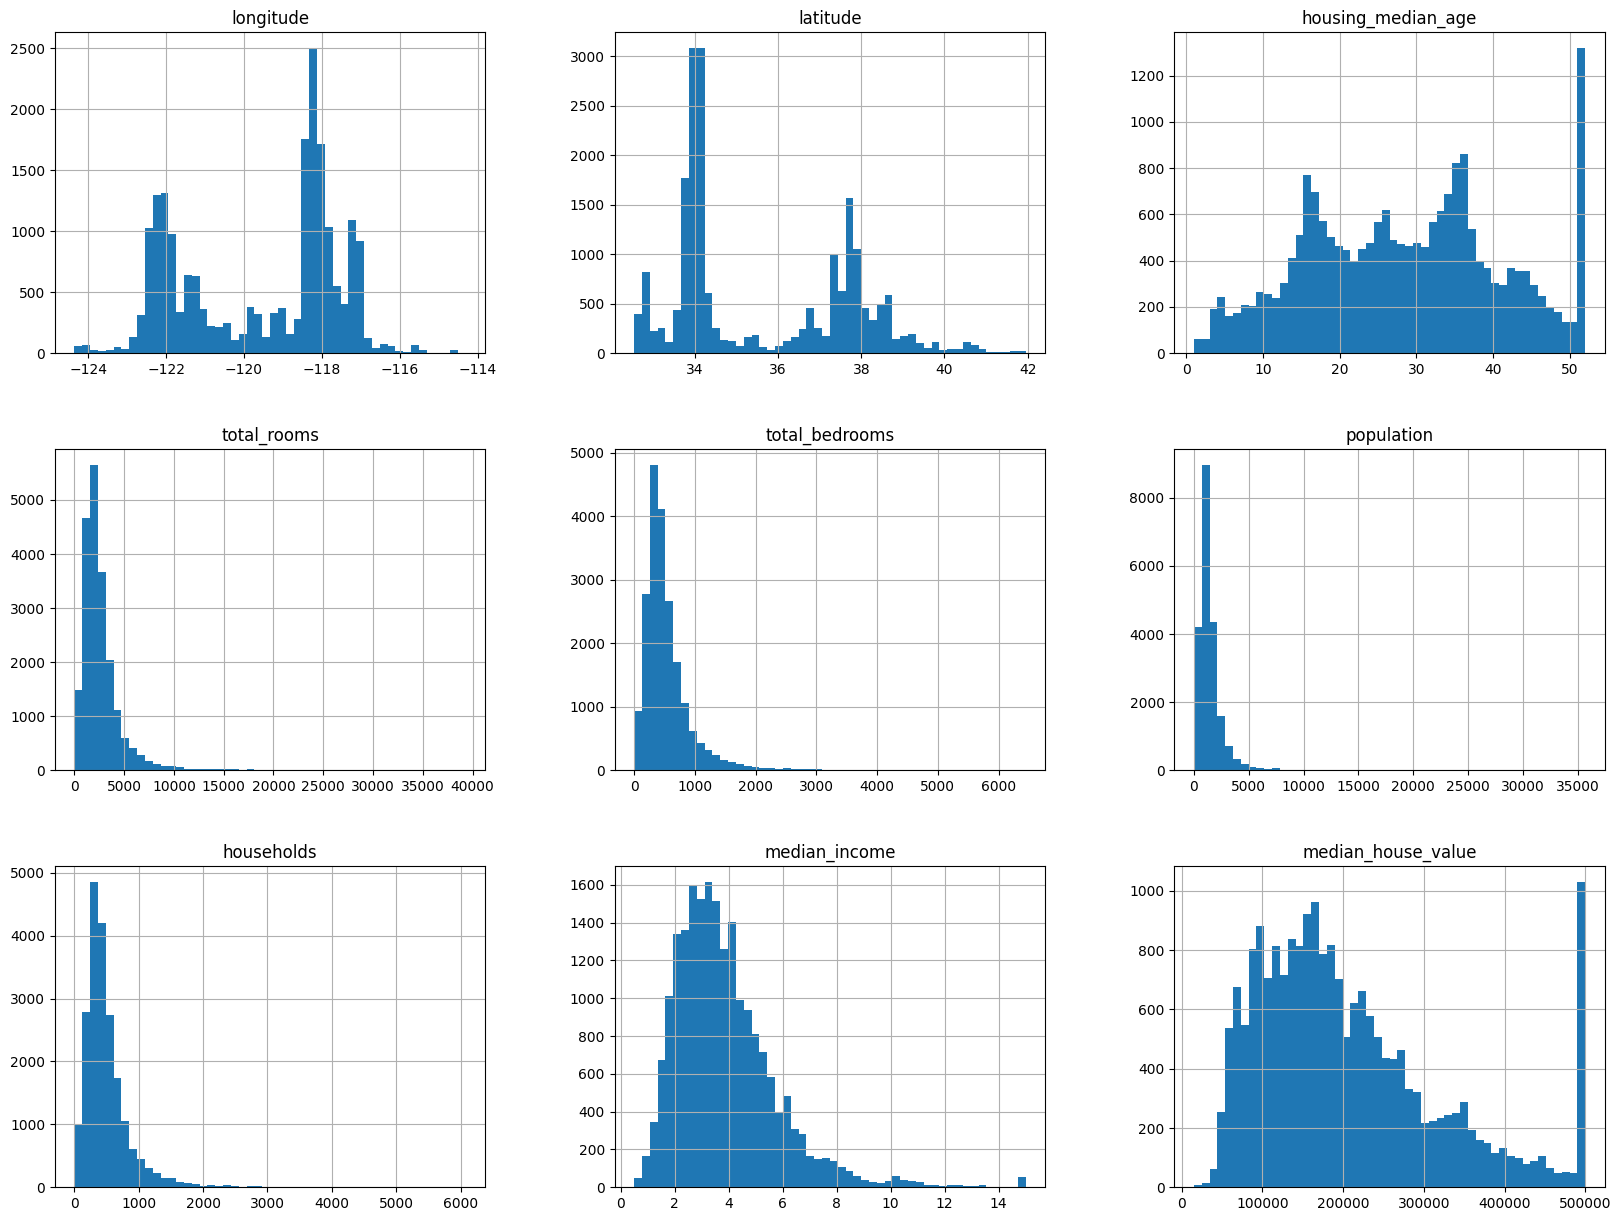

In [8]:
#Representar el histograma de housing
housing.hist(bins=50,figsize=(20,15))

#**Usaremos el método OneHotEncoder para transformar el campo ocean_proximity en columnas booleanas para cada categoria. Despues hay que concatenar el resultado con el dataframe original**

**Justificación:**
Si el atributo proximidad categórico ocean_proximity le asignasemos un valor numérico ordenado estamos introduciendo en los datos una noción de orden o magnitud que no tiene porque tener que ver con la realidad.

Veamos un ejemplo con el atributo color.

Imaginemos que rojo vale 1, verde vale 2 y azul vale 3.

La distancia entre el rojo y el azul es 2 y la del rojo al verde vale 1.

Estas distancias el modelo las puede interpretar como características de los datos que hay que aprender, y pueden distorsionar los resultados.

Con la codificación onehotencoder tendríamos lo siguiente:

rojo___verde___azul

1--------0------0

0--------1------0

0--------0------1


Las tres instancias de datos (una roja, otra verde y otra azul) tienen la misma distancia euclidiana, con lo cual desaparece el patrón de orden que el modelo podría aprender erroneamente.

La distancia de la primera instancia a la segunda es:

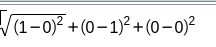

Y la distancia entre la primera y la tercera:

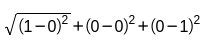

Y son la misma.


In [9]:
from sklearn.preprocessing import OneHotEncoder
housing_num = housing.drop("ocean_proximity", axis=1)
housing_cat = housing[["ocean_proximity"]]
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

housing_cat2=housing_cat_1hot.toarray()
housesCats=pd.DataFrame(housing_cat2,columns=cat_encoder.categories_[0])

print(housesCats.head())
houses_after_onehot=pd.concat([housing_num,housesCats],axis=1)
houses_after_onehot.head()

# print(housing_cat2.shape)
# print(housing_num.values.shape)
# pegado=np.c_[housing_num.values,housing_cat2]

# print(pegado.shape)
# pluscategorias=list(housing_num.columns)+list(cat_encoder.categories_[0])
# housing_catfinal=pd.DataFrame(pegado,columns=pluscategorias)
# housing_catfinal.head()

   <1H OCEAN  INLAND  ISLAND  NEAR BAY  NEAR OCEAN
0        0.0     0.0     0.0       1.0         0.0
1        0.0     0.0     0.0       1.0         0.0
2        0.0     0.0     0.0       1.0         0.0
3        0.0     0.0     0.0       1.0         0.0
4        0.0     0.0     0.0       1.0         0.0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


#

#**Con la matriz de dispersión podemos visualizar relaciones entre las diferentes columnas del data set. Ya se pueden intuir algunas relaciones lineales como por ejemplo entre los ingresos medios del distrito y el precio medio de las viviendas en cada distrito**

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

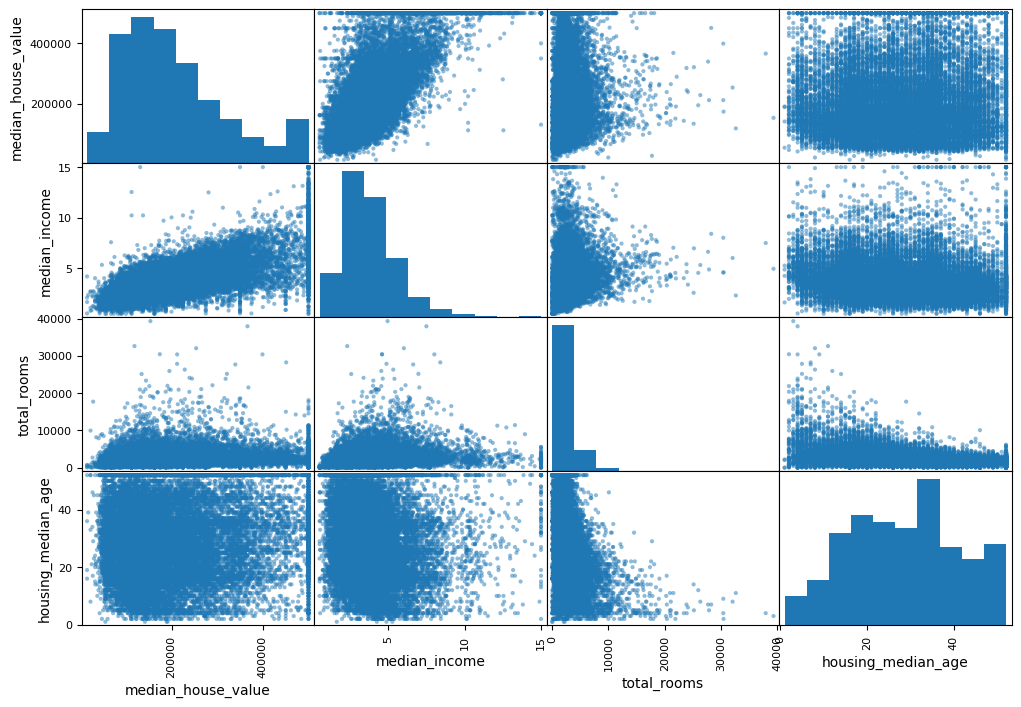

In [10]:


attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

#**Las correlaciones entre nuestros atributos de entrada y el atributo objetivo, nos van a dar idea de que datos serán importantes en nuestro modelo**
Oscilan entre los valores -1 y 1. Cuanto mas cercana a 1 más correlación positiva existe (Cuando crece un atributo crece el otro).
Si está cercana a 0 entonces no existe o hay muy poca correlación.
Si està cercanna a -1 la correlacion va en sentido inverso, cuanto más crece un atributo màs disminuye el otro

Matemáticamente se calcula así:

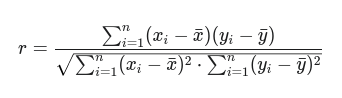

In [11]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


#La correlación no implica causalidad. Las ventas de helados y el número de urgencias atendidas en la playa tendrán seguramente un fuerte correlación. Pero la causa es el calor que hace ir a la gente a la playa y también aumenta la venta de helados (no solo en la playa)

#**Vamos a hacer el tratamiento de nulos en el atributo total_bedrooms que es el único que contiene nulos. Los nulos no podemos introducirlos en la mayoria de los modelos de aprendizaje automático, por eso hay que tratarlos**
Hay tres posibilidades:

1.- Eliminar toda la columna. Si hay demasiados nulos y el estudio de datos nos dice que no es significativa.

    housing.drop("total_bedrooms", axis=1)

2.- Eliminar las filas que contengan nulos. Si nos deja con suficientes datos para entrenamiento y pruebas.

    housing.dropna(subset=["total_bedrooms"], inplace=True)

3.- Rellenar los valores nulos con algún valor estadístico como la media o la mediana.

    median = housing["total_bedrooms"].median()  
    housing["total_bedrooms"].fillna(median, inplace=True)

In [12]:
#nos quedamos con la mediana por ser el menos destructivo con los datos, aunque también seria factible suprimir filas puesto que las
#que tienen nulos no son muchas

median = houses_after_onehot["total_bedrooms"].median()
houses_after_onehot["total_bedrooms"].fillna(median, inplace=True)
houses_after_onehot.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   <1H OCEAN           20640 non-null  float64
 10  INLAND              20640 non-null  float64
 11  ISLAND              20640 non-null  float64
 12  NEAR BAY            20640 non-null  float64
 13  NEAR OCEAN          20640 non-null  float64
dtypes: float64(14)
memory usage: 2.2 MB


/tmp/ipython-input-3998073634.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  houses_after_onehot["total_bedrooms"].fillna(median, inplace=True)


#**El campo total_bedrooms y total_rooms se refieren a todas las habitaciones de un distrito, serían  más significativos si considerasemos habitaciones/vivienda; dividiendo por el número house_holds que son las viviendas de cada distrito**

In [13]:
houses_after_onehot["rooms_per_household"] = houses_after_onehot["total_rooms"]/houses_after_onehot["households"]
houses_after_onehot["bedrooms_per_household"] = houses_after_onehot["total_bedrooms"]/houses_after_onehot["households"]

houses_after_onehot.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,rooms_per_household,bedrooms_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0,6.984127,1.023810
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0,6.238137,0.971880
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0,8.288136,1.073446
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0,5.817352,1.073059
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0,6.281853,1.081081


#**Vamos a seleccionar un set de entrenamiento y prueba que sea coherente con la distribución de datos de ingresos medios. Para no introducir un sesgo**

#**Aquí estamos creando un nuevo atributo del dataframe que contiene una categoria de ingresos.**
#**Para ello usamos cut  y unas divisiones (bins) que sean coherentes con el histograma de arriba**
#**Las labels nos dan las 5 categorias que necesitamos**

In [14]:



houses_after_onehot["income_cat"] = pd.cut(houses_after_onehot["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])



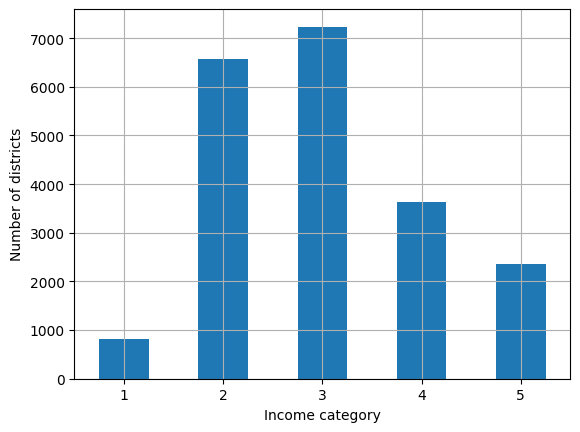

In [15]:
houses_after_onehot["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [16]:
houses_after_onehot["income_cat"].value_counts().sort_index()

,count
income_cat,
1,822
2,6581
3,7236
4,3639
5,2362


#**Con train_test_split de la librería scikit-learn, podemos dividir el dataset en parte de entrenamiento y pruebas. Con el parametro stratify pasandole la columna anterior, evitamos un posible sesgo por ingresos**

In [17]:
strat_train_set, strat_test_set = train_test_split(
    houses_after_onehot, test_size=0.2, stratify=houses_after_onehot["income_cat"], random_state=68)
train_tags=strat_train_set["median_house_value"]
test_tags=strat_test_set["median_house_value"]
strat_train_set.drop("median_house_value", axis=1, inplace=True)
strat_test_set.drop("median_house_value", axis=1, inplace=True)
print(strat_train_set['income_cat'].value_counts().sort_index())
print(strat_test_set['income_cat'].value_counts().sort_index())

income_cat
1     657
2    5265
3    5789
4    2911
5    1890
Name: count, dtype: int64
income_cat
1     165
2    1316
3    1447
4     728
5     472
Name: count, dtype: int64


<Axes: xlabel='income_cat'>

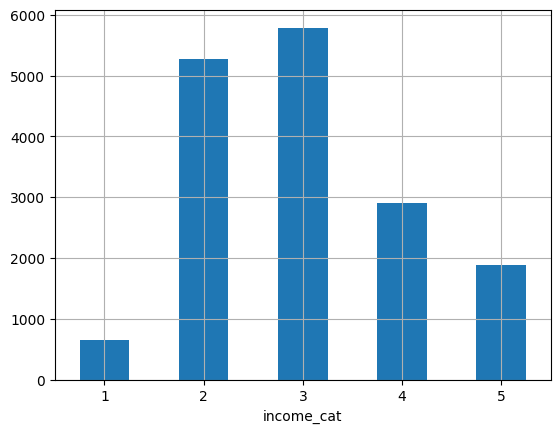

In [18]:
strat_train_set["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)


<Axes: xlabel='income_cat'>

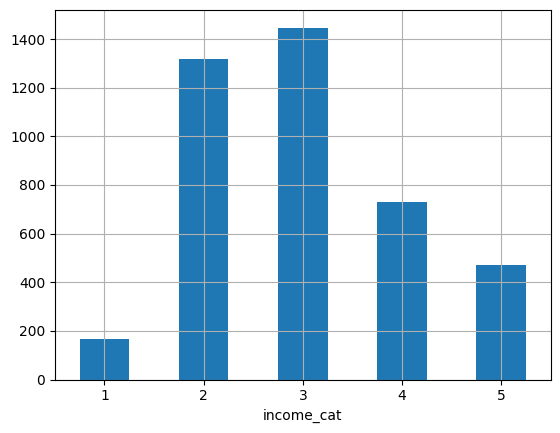

In [19]:
strat_test_set["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)

#**Normalización**

En este caso emplearemos la normalización estandar. A todos los datos le restamos su media, con lo cual los centramos alrededor de la media.
Luego los dividimos por la desviacion típica, con lo cual obtendremos en los datos normalizados obtendremos una desviacion típica de 1.

Nota:veremos más adelante algun ajuste previo de los datos para mejorar la normalización, sobre todo en distribuciones con cola pesada.

In [20]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
train_std_scaled = std_scaler.fit_transform(strat_train_set)
print(train_std_scaled)

test_std_scaled = std_scaler.transform(strat_test_set)
print(test_std_scaled)



[[-1.27532638  0.97929681 -0.28103213 ...  0.52372409 -0.44553359
   1.89007821]
 [ 0.85420111 -0.89715217  0.67053626 ... -0.80251634 -0.05845623
  -0.00643196]
 [ 0.56993163 -0.68136053 -0.51892423 ... -0.7999253  -0.2317699
  -0.95468705]
 ...
 [-0.73671053  1.07781038 -0.91541107 ...  0.01489903 -0.08690665
  -0.00643196]
 [ 0.81430364 -0.73296288 -0.28103213 ... -0.18690885  0.02913292
  -0.00643196]
 [ 2.62465137 -0.67666941 -1.0740058  ...  2.81009109  3.52102753
  -1.90294214]]
[[-0.86139012  1.42495344 -1.0740058  ... -0.21348789 -0.12035485
  -0.00643196]
 [-1.3301854   2.25997324 -0.1224374  ...  0.25490159 -0.06428965
  -0.00643196]
 [ 0.32555963 -0.67666941 -0.99470843 ... -0.6492625  -0.0963648
  -0.00643196]
 ...
 [ 0.67964968 -0.74234513 -0.04314003 ... -1.25869344  0.02879497
  -0.95468705]
 [ 1.19332961 -1.31935319 -0.28103213 ...  0.08744204 -0.29325031
   0.94182312]
 [ 0.87913703 -0.91122553 -1.86697946 ... -0.46350952 -0.45825444
  -0.95468705]]


#**Aplicamos la regresión lineal**

In [21]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(train_std_scaled, train_tags.to_frame())
#hacemos la prediccion de los datos de test con el modelo
predicciones=model.predict(test_std_scaled)
Ys=test_tags.to_frame()
Ys.reset_index(inplace=True,drop=True)
preds=pd.DataFrame(predicciones,columns=["Predicciones"])
preds.reset_index(inplace=True,drop=True)
comparativa=pd.concat([Ys,preds],axis=1)
comparativa

(4128, 1)
(4128, 1)


,median_house_value,Predicciones
0,119800.0,122690.708934
1,80600.0,115144.188466
2,130400.0,212353.621827
3,95200.0,129558.552734
4,180000.0,203308.822380
...,...,...
4123,142800.0,170294.879915
4124,442900.0,254142.450739
4125,151600.0,110750.578265
4126,162300.0,262375.212230


In [25]:
#Calculamos el error absoluto medio entre las predicciones y las etiquetas
from sklearn.metrics import mean_absolute_error
y_true = Ys.iloc[:, 0].values # Valores reales (median_house_value)
y_pred = preds.iloc[:, 0].values # Valores predichos

mae = mean_absolute_error(y_true,y_pred)
print(f"El Error Absoluto Medio (MAE) es: {mae}")

El Error Absoluto Medio (MAE) es: 50421.0795116052


In [26]:



epsilon = 1e-10

mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

print(f"El Error Absoluto Porcentual Medio (MAPE) es: {mape:.2f}%")

El Error Absoluto Porcentual Medio (MAPE) es: 28.88%


Text(0, 0.5, 'Precios')

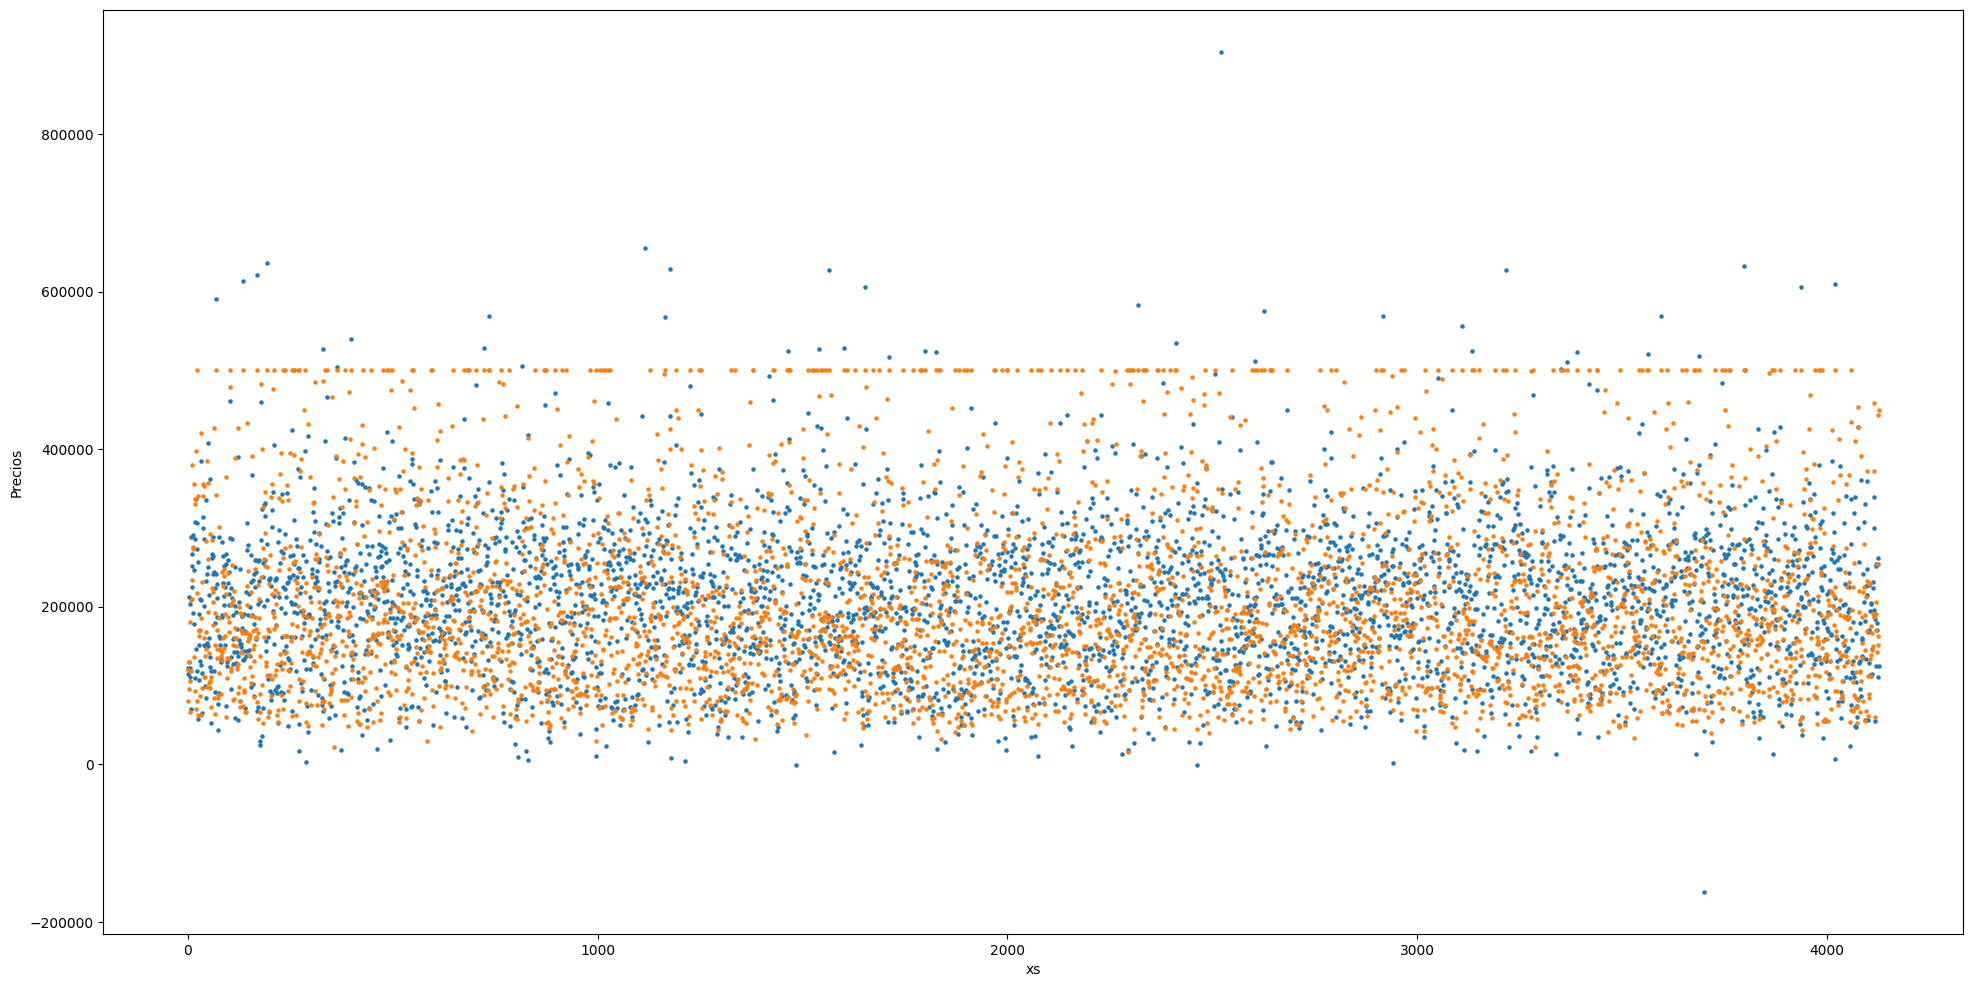

In [23]:
#Representar en una gráfica las predicciones y las etiquetas
import matplotlib.pyplot as plt
plt.figure(figsize=(24, 12))
Xs=np.arange(preds.shape[0])
plt.scatter(Xs, preds,s=5)
plt.scatter(Xs, Ys,s=5)
plt.xlabel("xs")
plt.ylabel("Precios")